In [ ]:
import json
import os
dataset_folder="" #dataset folder

dataset=list()
with open(os.path.join(dataset_folder,"train.json"), "r", newline="") as f:
    train=json.load(f)

with open(os.path.join(dataset_folder,"val.json"), "r", newline="") as f:
    val=json.load(f)

with open(os.path.join(dataset_folder,"test-real.json"), "r", newline="") as f:
    test=json.load(f)

dataset.extend(train)
dataset.extend(val)
dataset.extend(test)
print(len(dataset))
print(len(train))
print(len(val))
print(len(test))

300
257
28
15


In [ ]:
dataset[0:1]

[{'doc_id': 1,
  'text': 'cfdbdaa9-4017-402b-b795-f1bfcd947b23\r\n\r\n57 anos, raça leucodermica, casada e com dois filhos. Empregada de escritório.\r\n\r\nContactos: 966123456, marido 925678901.\r\n\r\nEtiologia DRC: Glomerulonefrite crônica.\r\nInicio de HD: 10/5/18.\r\nTransfusões: sim, duas transfusões de sangue em 2020.\r\nGravidezes - 2\r\nTransplante prévio - Não\r\n\r\nANTECEDENTES PESSOAIS:\r\n# Glomerulonefrite crônica\r\n- seguida em consulta de Nefrologia;\r\n- iniciou HD em maio de 2018; com evolução favorável.\r\n# FRCV: HTA, dislipidemia\r\n# IM moderada\r\n- ECG (dez/2020): RS, FC ~80bpm;\r\n- ecoTT (ago/2020): dilatação moderada da AE. Dilatação do anel mitral, com IM de grau moderado. IT ligeira, PSAP 25mmHg+pVC. FSVE conservada, FE 55%. Sem alterações da contractilidade segmentar. VCI Ok. Derrame pericárdico mínimo.\r\n# Antecedentes ginecológicos/obstétricos: partos normais; menopausa aos 52 anos; sem THS\r\n# Antecedentes cirúrgicos: cesariana e histerectomia\r\n# 

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")

def count_bertimbau_tokens(text: str, add_special_tokens: bool = True) -> int:
    encoded = tokenizer.encode(text, add_special_tokens=add_special_tokens)
    return len(encoded)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
#count number of tokens in dataset
#aggregate texts

count=0
for i in range(len(dataset)):
    tokens_entrie=count_bertimbau_tokens(dataset[i]["text"])
    dataset[i]["#tokens"]=tokens_entrie
    count=count+tokens_entrie



In [ ]:
count

274911

In [ ]:
dataset[90]["annotations"]

[{'label': 'Medicação Habitual',
  'diagnostico': None,
  'Polaridade': None,
  'ICD10': None,
  'EDQM': '318420003',
  'begin': 341,
  'end': 357},
 {'label': 'Medicação Habitual',
  'diagnostico': None,
  'Polaridade': None,
  'ICD10': None,
  'EDQM': '319997009',
  'begin': 362,
  'end': 382},
 {'label': 'Medicação Habitual',
  'diagnostico': None,
  'Polaridade': None,
  'ICD10': None,
  'EDQM': '1197380000',
  'begin': 387,
  'end': 404},
 {'label': 'Medicação Habitual',
  'diagnostico': None,
  'Polaridade': None,
  'ICD10': None,
  'EDQM': '317306008',
  'begin': 409,
  'end': 426},
 {'label': 'Alergias medicamentosas',
  'diagnostico': None,
  'Polaridade': 'Negativa',
  'ICD10': None,
  'EDQM': None,
  'begin': 680,
  'end': 703}]

In [ ]:
#count annotations

usual_medication=[]
diagnose=[]
drug_allergies=[]
not_drug_allergies=[]

for entry in dataset:
  for annotation in entry["annotations"]:
    if annotation["label"]=="Medicação Habitual":
      usual_medication.append(annotation)
    elif annotation["label"]=="Diagnóstico":
      diagnose.append(annotation)
    elif annotation["label"]=="Alergias medicamentosas":
      if(annotation["Polaridade"]=="Negativa"):
        not_drug_allergies.append(annotation)
      else:
        drug_allergies.append(annotation)

print(len(usual_medication))
print(len(diagnose))
print(len(drug_allergies))
print(len(not_drug_allergies))
print(len(drug_allergies)+len(not_drug_allergies))
print(len(usual_medication)+len(diagnose)+len(drug_allergies)+len(not_drug_allergies))

1300
185
163
96
259
1744


In [ ]:
#see represenation of the different entities
diagnose_text=list()
drug_allergies_text=list()
usual_medication_text=list()


for entry in dataset:
  for annotation in entry["annotations"]:
    if annotation["label"]=="Medicação Habitual":
      usual_medication_text.append(entry["text"][annotation["begin"]:annotation["end"]])
    elif annotation["label"]=="Diagnóstico":
      diagnose_text.append((entry["text"][annotation["begin"]:annotation["end"]]))
    elif annotation["label"]=="Alergias medicamentosas":
       drug_allergies_text.append(entry["text"][annotation["begin"]:annotation["end"]])

In [ ]:
from collections import Counter

usual_medication_text=[x.lower().strip() for x in usual_medication_text ]
diagnose_text=[x.lower().strip() for x in diagnose_text ]
drug_allergies_text=[x.lower().strip() for x in drug_allergies_text ]

print(Counter(usual_medication_text).most_common(10))
print(Counter(diagnose_text).most_common(10))
print(Counter(drug_allergies_text).most_common(10))

[('omeprazol 20mg id', 17), ('omeprazol 20mg 1cp em jejum', 17), ('atorvastatina 20mg id', 16), ('metformina', 16), ('atorvastatina', 14), ('omeprazol', 13), ('enalapril', 10), ('colecalciferol/carbonato de cálcio 1id de manhã', 10), ('bicarbonato 2id > id', 9), ('diulo 5 mg id', 9)]
[('doença renal crónica', 7), ('insuficiência renal aguda', 6), ('pneumonia adquirida na comunidade', 5), ('doença de crohn', 5), ('pneumonia bacteriana', 5), ('angina instável', 4), ('embolia pulmonar aguda', 3), ('dpoc', 3), ('insuficiência cardíaca descompensada', 3), ('gripe b', 3)]
[('penicilina', 71), ('alergias medicamentosas', 64), ('amoxicilina', 22), ('sulfonamidas', 18), ('alergia medicamentosa', 14), ('alergias', 10), ('aspirina', 6), ('alergia', 5), ('cefalexina', 5), ('cefalosporinas', 4)]


In [ ]:
Counter(drug_allergies_text).most_common(10)

[('penicilina', 71),
 ('alergias medicamentosas', 64),
 ('amoxicilina', 22),
 ('sulfonamidas', 18),
 ('alergia medicamentosa', 14),
 ('alergias', 10),
 ('aspirina', 6),
 ('alergia', 5),
 ('cefalexina', 5),
 ('cefalosporinas', 4)]

In [ ]:
#average span length per entity group

um_span=[count_bertimbau_tokens(x) for x in usual_medication_text]
d_span=[count_bertimbau_tokens(x) for x in diagnose_text]
da_span=[count_bertimbau_tokens(x) for x in drug_allergies_text]

In [ ]:
#average and std
import numpy as np
#convert to numpy array
um_span=np.array(um_span)
d_span=np.array(d_span)
da_span=np.array(da_span)
#compute average and std
print(um_span.mean(),um_span.std())
print(d_span.mean(),d_span.std())
print(da_span.mean(),da_span.std())

11.933076923076923 4.75565879059299
8.421621621621622 4.337836995874298
5.667953667953668 1.0237413695244202


#Splits

In [ ]:
dataset_entities=list()
count=0
for entry in train:
  for annotation in entry["annotations"]:
    temp=dict()
    temp["id"]=count
    temp["label"]=annotation["label"]
    temp["split"]="train"
    count=+1
    dataset_entities.append(temp)

for entry in val:
  for annotation in entry["annotations"]:
    temp=dict()
    temp["id"]=count
    temp["label"]=annotation["label"]
    temp["split"]="val"
    count=+1
    dataset_entities.append(temp)

for entry in test:
  for annotation in entry["annotations"]:
    temp=dict()
    temp["id"]=count
    temp["polarity"]=annotation["Polaridade"]
    temp["label"]=annotation["label"]
    temp["split"]="test"
    count=+1
    dataset_entities.append(temp)

In [ ]:
import pandas as pd
dataset_entities_df=pd.DataFrame.from_dict(dataset_entities)

label_mapping = {
    'Alergias medicamentosas': 'Medication Allergies',
    'Medicação Habitual': 'Usual Medication',
    'Diagnóstico': 'Diagnosis'
}
dataset_entities_df['abbreviated_label'] = dataset_entities_df['label'].map(label_mapping)

In [ ]:
dataset_entities_df

,id,label,split,polarity,abbreviated_label
0,0,Alergias medicamentosas,train,NaN,Medication Allergies
1,1,Medicação Habitual,train,NaN,Usual Medication
2,1,Medicação Habitual,train,NaN,Usual Medication
3,1,Medicação Habitual,train,NaN,Usual Medication
4,1,Medicação Habitual,train,NaN,Usual Medication
...,...,...,...,...,...
1740,1,Medicação Habitual,test,None,Usual Medication
1741,1,Medicação Habitual,test,None,Usual Medication
1742,1,Medicação Habitual,test,None,Usual Medication
1743,1,Alergias medicamentosas,test,Positiva,Medication Allergies


In [ ]:
#count labels per split
dataset_entities_df.groupby(['split', 'label',"polarity"]).size()

split  label                    polarity
test   Alergias medicamentosas  Negativa    4
                                Positiva    8
       Medicação Habitual       Positiva    1
dtype: int64

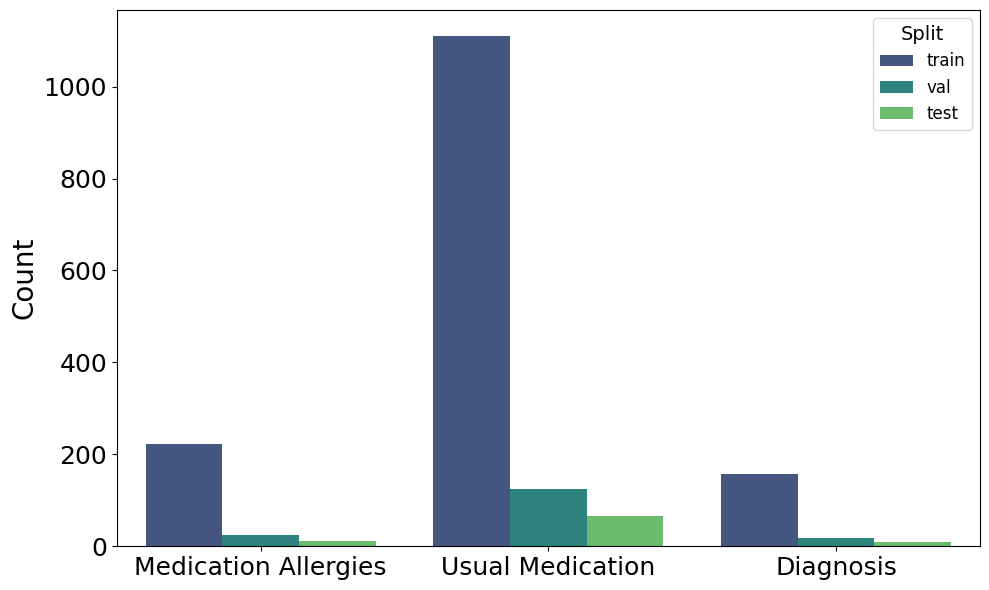

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# plot entities per split
plt.figure(figsize=(10, 6))
sns.countplot(data=dataset_entities_df, x='abbreviated_label', hue='split', palette='viridis')
plt.xlabel('', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(rotation=0, ha='center', fontsize=18) # Rotate x-axis labels for better readability and increase font size
plt.yticks(fontsize=18) # Increase y-tick label font siz6
plt.legend(title='Split', fontsize=12, title_fontsize=14) # Increase legend font size
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig("split_count.png")
plt.show()